In [1]:
%pip install -U langchain langchain-core langchain-community langchain-openai langchain-chroma langgraph ddgs youtube_search wikipedia

Note: you may need to restart the kernel to use updated packages.


In [11]:
from langchain_openai import ChatOpenAI

llm=ChatOpenAI(model="gpt-4o-mini")

question=input("Enter the question")

response=llm.invoke(question)
print(response.content)

"Gen AI," short for Generative Artificial Intelligence, refers to a category of AI models and systems designed to generate new content, ideas, or solutions based on the data they have been trained on. These systems can create text, images, music, code, and more, often by learning patterns from existing data and extending or transforming them in novel ways.

Key features of Generative AI include:

1. **Text Generation**: Models like OpenAI's GPT (including ChatGPT) can generate coherent and contextually relevant text, making them useful for applications like chatbots, content creation, and more.

2. **Image Generation**: Tools like DALL-E or Midjourney can create images from textual descriptions, allowing users to visualize ideas or concepts that may not exist.

3. **Music and Audio Creation**: AI can generate music compositions, sound effects, and even audio synthesis, sometimes producing works that blend styles and genres.

4. **Video Generation**: Emerging technologies are allowing f

In [12]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

llm = ChatOpenAI(model="gpt-4o-mini")

# Zero-shot
zero_shot_prompt = "Classify this movie: 'The Conjuring' into genre."

# Few-shot
few_shot_prompt = """
Classify movies into genres:

Movie: Titanic → Romance
Movie: Avengers → Action
Movie: The Conjuring → ?
"""

print("🔹 Zero-shot:")
print(llm.invoke([HumanMessage(content=zero_shot_prompt)]).content)

print("\n🔹 Few-shot:")
print(llm.invoke([HumanMessage(content=few_shot_prompt)]).content)

🔹 Zero-shot:
'The Conjuring' is classified as a horror film. It combines elements of supernatural horror, thriller, and drama, focusing on paranormal investigations.

🔹 Few-shot:
Movie: The Conjuring → Horror


In [13]:
#DEMO 2 — Chain-of-Thought Prompting
cot_prompt = """
A movie has a rating of 9.2 and belongs to Sci-Fi.
Should we recommend it?

Think step by step.
"""

response = llm.invoke([HumanMessage(content=cot_prompt)])
print(response.content)

To determine if we should recommend the movie with a rating of 9.2 in the Sci-Fi genre, let's analyze the information step by step:

1. **Understand the context of the rating**:
   - A rating of 9.2 is generally considered very high. Most rating systems (like IMDb) utilize a scale from 1 to 10, with higher scores indicating better quality. A score above 9 typically signifies that the movie is highly regarded by audiences.

2. **Genre consideration**:
   - The movie falls under the Sci-Fi genre. It's important to consider the preferences of the audience:
     - If the audience enjoys Sci-Fi films or is looking for something in this genre, a high-rated Sci-Fi film might be very appealing.

3. **Audience demographic**:
   - Depending on who we recommend this movie to, we should consider if they like Sci-Fi films. If the audience has a history of enjoying other Sci-Fi movies or similar high-rated films, it makes a strong case for recommending this one.

4. **Comparative analysis**:
   - Ch

DEMO 3 — Tool Calling (Core Agent Concept)

In [12]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools import YouTubeSearchTool

search = DuckDuckGoSearchRun()

search.invoke("Obama's first name?")

"In February 1981,Obamamade hisfirstpublic speech, calling for Occidental to participate in the disinvestment from South Africa in response to ... ... searching our database we found 1 possible solution for the: ... The solution we have for PresidentObama'sfirstnamehas a total of 6 letters. According to the BBC , Odinga claimsObamaas afirstcousin.) We should eschew guilt by association, but the echoes resound. Oh did we mention that Dorne Ayers Wif got MichilleObamasWife herfirstJob at a Law Firm in Chicago and the whole Bunch lives in the same ... ... a long list of schools now named for him, like BarackObama...Obamaeven has animal species named after him, like placida barackobamai, a sea slug."

In [13]:
from langchain_community.tools import YouTubeSearchTool

youtube = YouTubeSearchTool()

youtube.invoke("databricks Data master?")


"['https://www.youtube.com/watch?v=Q53fDXd_X68&pp=ygUXZGF0YWJyaWNrcyBEYXRhIG1hc3Rlcj8%3D', 'https://www.youtube.com/watch?v=KnGPPCYWp5g&pp=ygUXZGF0YWJyaWNrcyBEYXRhIG1hc3Rlcj8%3D']"

In [14]:
from langchain_openai import ChatOpenAI
from langchain_community.tools import DuckDuckGoSearchRun, YouTubeSearchTool
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent

# LLM
llm = ChatOpenAI(model="gpt-4o-mini")

# Tools
tools = [
    DuckDuckGoSearchRun(),
    YouTubeSearchTool()
]

# Create agent (LangGraph way)
agent = create_react_agent(llm, tools)

# Chat loop
print("🎬 Movie Assistant Ready!")
movie_type = input("Enter the type of movie: ")

query = f"Suggest a {movie_type} movie and include a short summary and trailer if possible."

# Invoke agent
response = agent.invoke({
    "messages": [HumanMessage(content=query)]
})

# Extract final answer
print("\n✅ Response:\n")
print(response["messages"][-1].content)

🎬 Movie Assistant Ready!


/var/folders/df/3h4x8jc91xb09q76lzkq4bqh0000gn/T/ipykernel_10235/4188841437.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools)



✅ Response:

### Dhurandhar: The Revenge (Dhurandhar2)

**Release Date:** December 5, 2025  
**Director:** Aditya Dhar  
**Cast:** Ranveer Singh, Akshaye Khanna, Sanjay Dutt, Arjun Rampal, R. Madhavan, and others

**Synopsis:**  
"Dhurandhar: The Revenge" is an Indian Hindi-language spy action thriller that follows the gripping tale of revenge and intrigue as Dhurandhar, played by Ranveer Singh, navigates a treacherous world filled with danger and deception. Set against a backdrop of espionage and high-stakes action, the film unfolds a complex narrative involving betrayal and justice.

The movie promises thrilling sequences and intense performances, as Dhurandhar seeks to unveil the enemies lurking in the shadows and confront his past.

**Trailers:**  
You can watch the trailers for "Dhurandhar: The Revenge" here:
- [Trailer 1](https://www.youtube.com/watch?v=NHk7scrb_9I&pp=ygUTRGh1cmFuZGhhcjIgdHJhaWxlcg%3D%3D)
- [Trailer 2](https://www.youtube.com/watch?v=Ox5v6Walpa8&pp=ygUTRGh1cmFuZ

In [15]:
chat_history = []

chat_history.append(HumanMessage(content="I like action movies"))

chat_history.append(HumanMessage(content="Suggest a movie"))

response = llm.invoke(chat_history)

print(response.content)

If you enjoy action movies, you might like **"Mad Max: Fury Road."** It's a high-octane thrill ride set in a post-apocalyptic world, featuring stunning visuals and intense chase sequences. The film is directed by George Miller and has received critical acclaim for its action choreography and performances. If you've already seen it, let me know, and I can suggest something else!


In [15]:
import tiktoken

enc = tiktoken.encoding_for_model("gpt-4o-mini")

text = "Suggest a sci-fi movie with explanation"

tokens = enc.encode(text)

print("Token count:", len(tokens))

Token count: 7


In [16]:
from langgraph.graph import StateGraph
from typing import TypedDict

class State(TypedDict):
    input: str
    output: str

def step1(state):
    return {"output": f"Processed: {state['input']}"}

graph = StateGraph(State)

graph.add_node("step1", step1)
graph.set_entry_point("step1")

app = graph.compile()

result = app.invoke({"input": "Recommend movie"})
print(result)

{'input': 'Recommend movie', 'output': 'Processed: Recommend movie'}


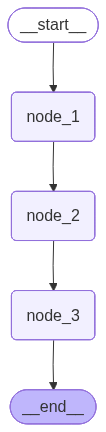

In [ ]:
#from dotenv import load_dotenv
import os
import random
from typing import Literal, TypedDict
from langchain_core.messages import AnyMessage, HumanMessage
from langgraph.graph.message import add_messages
from typing_extensions import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display



from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}



# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)





# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))



In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


# define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

#defined node 1
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

#defined node 2
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [7]:
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)


# compile the graph
workflow = graph.compile()

In [8]:
# execute the graph
intial_state = {'weight_kg':70, 'height_m':1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 70, 'height_m': 1.73, 'bmi': 23.39, 'category': 'Normal'}


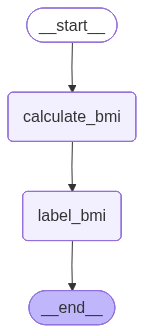

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [17]:
def decide(state):
    if "action" in state["input"].lower():
        return "action_node"
    return "default_node"

def action_node(state):
    return {"output": "Action movie recommended"}

def default_node(state):
    return {"output": "General movie recommended"}

graph = StateGraph(State)

graph.add_node("action_node", action_node)
graph.add_node("default_node", default_node)

graph.add_conditional_edges("action_node", decide)

graph.set_entry_point("action_node")

app = graph.compile()

print(app.invoke({"input": "I want action movie"}))

GraphRecursionError: Recursion limit of 10007 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT